# Tutorial 26 -- Frame Sanity Checks and Common Failure Modes

Demonstrate a few of the easiest ways to misread `cqed_sim` results: using the raw carrier instead of the physical transition detuning, comparing lab and rotating frames without noticing, and trusting too-small cutoffs.

**Prerequisites.** Tutorials 02, 06, and 20 are recommended first.


## 1. Goal

We will compare correct and incorrect spectroscopy setup choices and summarize the kinds of mistakes that show up most often when debugging notebook results.


## 2. Physical Background

Most cQED notebook mistakes are bookkeeping mistakes, not solver bugs. In this repository the two biggest ones are mislabeling the spectroscopy axis and forgetting which frame a transition frequency lives in.


## 3. Imports


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    BosonicModeSpec,
    DispersiveCouplingSpec,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SidebandDriveSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    coherent_state,
    compute_energy_spectrum,
    fock_state,
    manifold_transition_frequency,
    measure_qubit,
    prepare_simulation,
    prepare_state,
    pure_dephasing_time_from_t1_t2,
    qubit_state,
    run_rabi,
    run_ramsey,
    run_spectroscopy,
    run_t1,
    run_t2_echo,
    sideband_transition_frequency,
    simulate_batch,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.pulses import gaussian_envelope, square_envelope
from cqed_sim.sim import (
    cavity_wigner,
    conditioned_bloch_xyz,
    mode_moments,
    qubit_conditioned_mode_moments,
    readout_response_by_qubit_state,
    reduced_cavity_state,
    reduced_qubit_state,
    reduced_storage_state,
    storage_photon_number,
    subsystem_level_population,
    transmon_level_populations,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_ghz,
    angular_to_hz,
    angular_to_mhz,
    cross_kerr_conditional_phase,
    final_expectation,
    fit_echo_signal,
    fit_exponential_decay,
    fit_lorentzian_peak,
    fit_rabi_vs_amplitude,
    fit_rabi_vs_duration,
    fit_ramsey_signal,
    gaussian_quasistatic_echo_excited_population,
    gaussian_quasistatic_ramsey_excited_population,
    ns,
    ramsey_population,
    resonant_drive_excited_population,
    t1_relaxation_population,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 4. Simulation Parameters


In [2]:
detuning_mhz = np.linspace(-4.0, 4.0, 61)
probe_duration = 0.8 * us
probe_amplitude = MHz(0.08)
dt = 4.0 * ns


## 5. Model Construction


In [3]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.2),
    alpha=0.0,
    chi=0.0,
    kerr=0.0,
    n_cav=1,
    n_tr=2,
)
frame = FrameSpec(omega_q_frame=model.omega_q)
spectrum_levels = min(6, int(np.prod(model.subsystem_dims)))


## 6. Pulse / Sequence Construction


In [4]:
correct_response = []
wrong_response = []
for point_mhz in detuning_mhz:
    correct_probe = Pulse("q", 0.0, probe_duration, square_envelope, amp=probe_amplitude, carrier=carrier_for_transition_frequency(MHz(point_mhz)), label="correct")
    wrong_probe = Pulse("q", 0.0, probe_duration, square_envelope, amp=probe_amplitude, carrier=MHz(point_mhz), label="wrong")
    correct_compiled = SequenceCompiler(dt=dt).compile([correct_probe], t_end=probe_duration + dt)
    wrong_compiled = SequenceCompiler(dt=dt).compile([wrong_probe], t_end=probe_duration + dt)
    correct_result = simulate_sequence(model, correct_compiled, model.basis_state(0, 0), {"q": "qubit"}, config=SimulationConfig(frame=frame, max_step=dt))
    wrong_result = simulate_sequence(model, wrong_compiled, model.basis_state(0, 0), {"q": "qubit"}, config=SimulationConfig(frame=frame, max_step=dt))
    correct_response.append(final_expectation(correct_result, "P_e"))
    wrong_response.append(final_expectation(wrong_result, "P_e"))
correct_response = np.asarray(correct_response, dtype=float)
wrong_response = np.asarray(wrong_response, dtype=float)
matched_spectrum = compute_energy_spectrum(model, frame=frame, levels=spectrum_levels)
lab_spectrum = compute_energy_spectrum(model, frame=FrameSpec(), levels=spectrum_levels)


## 7. Running the Simulation


In [5]:
correct_peak = float(detuning_mhz[int(np.argmax(correct_response))])
wrong_peak = float(detuning_mhz[int(np.argmax(wrong_response))])
print(f"Correct carrier mapping peak detuning [MHz]: {correct_peak:+.3f}")
print(f"Wrong raw-carrier scan peak detuning [MHz]: {wrong_peak:+.3f}")
print("Matched-frame low energies [MHz]:", np.round(matched_spectrum.energies[:4] / (2.0 * np.pi * 1.0e6), 4))
print("Lab-frame low energies [MHz]:", np.round(lab_spectrum.energies[:4] / (2.0 * np.pi * 1.0e6), 4))


Correct carrier mapping peak detuning [MHz]: +0.000
Wrong raw-carrier scan peak detuning [MHz]: +0.000
Matched-frame low energies [MHz]: [-0.  0.]
Lab-frame low energies [MHz]: [   0. 6200.]


## 8. Visualizing the Results


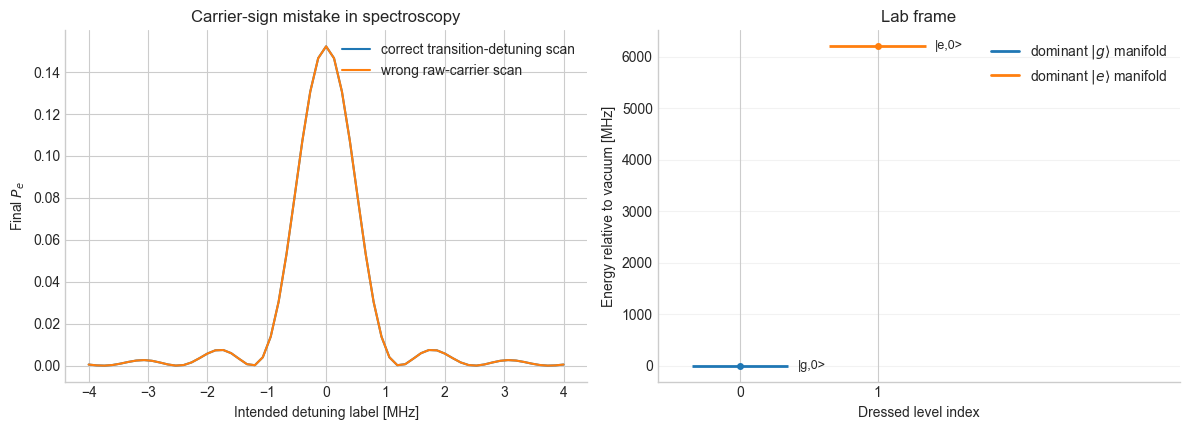

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
axes[0].plot(detuning_mhz, correct_response, label="correct transition-detuning scan")
axes[0].plot(detuning_mhz, wrong_response, label="wrong raw-carrier scan")
axes[0].set_xlabel("Intended detuning label [MHz]")
axes[0].set_ylabel(r"Final $P_e$")
axes[0].set_title("Carrier-sign mistake in spectroscopy")
axes[0].legend()

plot_energy_levels(lab_spectrum, max_levels=spectrum_levels, energy_scale=1.0 / (2.0 * np.pi * 1.0e6), energy_unit_label="MHz", title="Lab frame", ax=axes[1])
plt.show()


## 9. Physical Interpretation

The raw-carrier scan is not just mislabeled; it moves the resonance to the wrong side of the axis because the waveform convention flips the sign. The frame-energy comparison is the other routine footgun: a matched rotating frame can make the same physical system look numerically tiny compared with the lab frame.


## 10. Exercises / Next Steps

- Repeat the carrier-sign comparison in Tutorial 07 and watch the number-splitting lines mirror incorrectly.
- Pair this notebook with Tutorial 20 whenever a result looks suspiciously truncation-dependent.
- Use this notebook as a quick debugging checklist whenever a new workflow seems to disagree with intuition.
